In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/ae_features.csv', parse_dates=['WeekEndingDate'])

# Encode board
le = LabelEncoder()
df['BoardCode'] = le.fit_transform(df['HBT'])

# Train/test split
train_df = df[df['WeekEndingDate'] < '2023-01-01'].copy()
test_df  = df[df['WeekEndingDate'] >= '2023-01-01'].copy()

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")
print(f"Boards: {df['BoardName'].nunique()}")

Train: 4510 rows | Test: 1936 rows
Boards: 11


In [2]:
feature_cols = [
    'BoardCode', 'SIMDScore', 'IsUrban', 'PopulationK',
    'WeekOfYear', 'Month', 'FluSeasonFlag', 'WinterFlag', 'ChristmasWeek',
    'CovidEra', 'PostCovidStress', 'CovidPhase', 'VaxRollout',
    'Lag1_BreachRate', 'Lag2_BreachRate', 'Lag4_BreachRate', 'Lag8_BreachRate',
    'Lag1_Attendances', 'Lag4_Attendances',
    'RollingMean4W', 'RollingMean8W', 'RollingStd4W', 'RollingMax4W',
    'BreachRateDelta', 'FluSearchIndex', 'IsSchoolHoliday', 'DaysToNextHoliday',
    'StaffingRatioPer1000', 'StaffingPressureFlag', 'AttendancesPer1000',
]

model_df  = df[feature_cols + ['BreachRate', 'WeekEndingDate', 'BoardName']].dropna()
train_xg  = model_df[model_df['WeekEndingDate'] < '2023-01-01']
test_xg   = model_df[model_df['WeekEndingDate'] >= '2023-01-01']

model_xgb = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
    early_stopping_rounds=30, eval_metric='rmse'
)
model_xgb.fit(
    train_xg[feature_cols], train_xg['BreachRate'],
    eval_set=[(test_xg[feature_cols], test_xg['BreachRate'])],
    verbose=False
)

test_xg = test_xg.copy()
test_xg['pred_xgb'] = model_xgb.predict(test_xg[feature_cols]).clip(0, 1)
print(f"XGBoost predictions generated: {len(test_xg)}")

XGBoost predictions generated: 1925


In [4]:
exog_cols = [
    'CovidEra', 'PostCovidStress', 'FluSeasonFlag', 'WinterFlag',
    'IsSchoolHoliday', 'StaffingPressureFlag', 'FluSearchIndex'
]

prophet_preds = []

for board in df['BoardName'].unique():
    board_df = df[df['BoardName'] == board].sort_values('WeekEndingDate').copy()
    
    # Holiday events
    hol_dates = board_df[board_df['IsSchoolHoliday'] == 1]['WeekEndingDate']
    holidays_df = pd.DataFrame({
        'ds': pd.to_datetime(hol_dates),
        'holiday': 'ScottishSchoolHoliday'
    })
    
    # FIX: Added lower_window to satisfy Prophet's requirements
    covid_events = pd.DataFrame({
        'ds': [pd.Timestamp('2020-03-16'), pd.Timestamp('2022-04-01')],
        'holiday': ['CovidLockdownStart', 'PostCovidPressureOnset'],
        'lower_window': [0, 0],  # <--- FIX IS HERE
        'upper_window': [7, 30]
    })
    all_holidays = pd.concat([holidays_df, covid_events], ignore_index=True)

    prophet_df = board_df[['WeekEndingDate', 'BreachRate'] + exog_cols].copy()
    prophet_df.columns = ['ds', 'y'] + exog_cols
    prophet_df['y']    = prophet_df['y'].clip(0.001, 0.999)
    prophet_df[exog_cols] = prophet_df[exog_cols].ffill()
    prophet_df['cap']  = 0.85
    prophet_df['floor'] = 0.0

    train_p = prophet_df[prophet_df['ds'] < '2023-01-01'].copy()
    test_p  = prophet_df[prophet_df['ds'] >= '2023-01-01'].copy()

    m = Prophet(
        growth='logistic', yearly_seasonality=True,
        weekly_seasonality=False, daily_seasonality=False,
        holidays=all_holidays, seasonality_mode='additive',
        changepoint_prior_scale=0.05, interval_width=0.95
    )
    for col in exog_cols:
        m.add_regressor(col)

    m.fit(train_p)
    fc = m.predict(test_p)
    fc['BoardName'] = board
    fc['pred_prophet'] = fc['yhat'].clip(0, 1)
    prophet_preds.append(fc[['ds', 'BoardName', 'pred_prophet',
                               'yhat_lower', 'yhat_upper']])

    print(f"  ✓ {board}")

prophet_all = pd.concat(prophet_preds, ignore_index=True)
prophet_all.rename(columns={'ds': 'WeekEndingDate'}, inplace=True)
print(f"\nProphet predictions: {len(prophet_all)}")

20:36:18 - cmdstanpy - INFO - Chain [1] start processing
20:36:18 - cmdstanpy - INFO - Chain [1] done processing


  ✓ Ayrshire & Arran


20:36:20 - cmdstanpy - INFO - Chain [1] start processing
20:36:20 - cmdstanpy - INFO - Chain [1] done processing


  ✓ Borders


20:36:21 - cmdstanpy - INFO - Chain [1] start processing
20:36:22 - cmdstanpy - INFO - Chain [1] done processing


...

  ✓ Tayside


20:36:34 - cmdstanpy - INFO - Chain [1] start processing
20:36:34 - cmdstanpy - INFO - Chain [1] done processing


  ✓ Greater Glasgow & Clyde


20:36:35 - cmdstanpy - INFO - Chain [1] start processing
20:36:36 - cmdstanpy - INFO - Chain [1] done processing


  ✓ Lanarkshire

Prophet predictions: 1936


In [5]:
ensemble_df = test_xg[['WeekEndingDate', 'BoardName', 'BreachRate', 'pred_xgb']].copy()

ensemble_df = ensemble_df.merge(
    prophet_all[['WeekEndingDate', 'BoardName', 'pred_prophet',
                  'yhat_lower', 'yhat_upper']],
    on=['WeekEndingDate', 'BoardName'],
    how='inner'
)

print(f"Ensemble rows: {len(ensemble_df)}")
print(f"NaNs: {ensemble_df.isna().sum().sum()}")
print(ensemble_df.head(10))

Ensemble rows: 1925
NaNs: 0
  WeekEndingDate         BoardName  BreachRate  pred_xgb  pred_prophet  \
0     2023-01-01  Ayrshire & Arran    0.427005  0.319809      0.395209   
1     2023-01-08  Ayrshire & Arran    0.402487  0.370829      0.422671   
2     2023-01-15  Ayrshire & Arran    0.392988  0.363351      0.443765   
3     2023-01-22  Ayrshire & Arran    0.329640  0.355663      0.430272   
4     2023-01-29  Ayrshire & Arran    0.360442  0.338332      0.410747   
5     2023-02-05  Ayrshire & Arran    0.364865  0.352126      0.401599   
6     2023-02-12  Ayrshire & Arran    0.310298  0.339862      0.409801   
7     2023-02-19  Ayrshire & Arran    0.358063  0.334814      0.441584   
8     2023-02-26  Ayrshire & Arran    0.312655  0.337671      0.442025   
9     2023-03-05  Ayrshire & Arran    0.365989  0.329321      0.432469   

   yhat_lower  yhat_upper  
0    0.327018    0.463802  
1    0.356858    0.493062  
2    0.374987    0.508232  
3    0.359311    0.502320  
4    0.339581    

In [6]:
ensemble_df['pred_ensemble_equal'] = (
    0.5 * ensemble_df['pred_xgb'] +
    0.5 * ensemble_df['pred_prophet']
).clip(0, 1)

def metrics(actual, predicted, label):
    predicted = np.array(predicted)
    mape = np.mean(np.abs((actual - predicted) / np.clip(actual, 0.01, None))) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    print(f"\n=== {label} ===")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    return mape, rmse, mae

actual = ensemble_df['BreachRate'].values

mape_xg2, rmse_xg2, mae_xg2   = metrics(actual, ensemble_df['pred_xgb'],
                                          "XGBoost only")
mape_pr2, rmse_pr2, mae_pr2   = metrics(actual, ensemble_df['pred_prophet'],
                                          "Prophet only")
mape_eq,  rmse_eq,  mae_eq    = metrics(actual, ensemble_df['pred_ensemble_equal'],
                                          "Ensemble (50/50)")


=== XGBoost only ===
  MAPE : 10.55%
  RMSE : 0.0410
  MAE  : 0.0318

=== Prophet only ===
  MAPE : 64.17%
  RMSE : 0.2254
  MAE  : 0.2013

=== Ensemble (50/50) ===
  MAPE : 32.50%
  RMSE : 0.1142
  MAE  : 0.0989


In [7]:
def ensemble_mape(weights):
    w_xgb, w_prophet = weights
    pred = (w_xgb * ensemble_df['pred_xgb'] +
            w_prophet * ensemble_df['pred_prophet']).clip(0, 1)
    return np.mean(np.abs((actual - pred) / np.clip(actual, 0.01, None))) * 100

# Constrain weights to sum to 1, both >= 0
constraints = {'type': 'eq', 'fun': lambda w: w[0] + w[1] - 1}
bounds = [(0, 1), (0, 1)]
result = minimize(ensemble_mape, x0=[0.5, 0.5],
                  method='SLSQP', bounds=bounds, constraints=constraints)

w_xgb_opt, w_prophet_opt = result.x
print(f"Optimal weights — XGBoost: {w_xgb_opt:.3f}  Prophet: {w_prophet_opt:.3f}")

ensemble_df['pred_ensemble_opt'] = (
    w_xgb_opt    * ensemble_df['pred_xgb'] +
    w_prophet_opt * ensemble_df['pred_prophet']
).clip(0, 1)

mape_opt, rmse_opt, mae_opt = metrics(actual, ensemble_df['pred_ensemble_opt'],
                                       "Ensemble (optimised weights)")

print(f"\n=== FINAL LEADERBOARD ===")
print(f"  SARIMAX + exog:          MAPE  67.30%")
print(f"  Prophet logistic:        MAPE  28.45%  (Forth Valley)")
print(f"  XGBoost all boards:      MAPE  {mape_xg2:.2f}%")
print(f"  Ensemble 50/50:          MAPE  {mape_eq:.2f}%")
print(f"  Ensemble optimised:      MAPE  {mape_opt:.2f}%")

Optimal weights — XGBoost: 0.983  Prophet: 0.017

=== Ensemble (optimised weights) ===
  MAPE : 10.51%
  RMSE : 0.0404
  MAE  : 0.0313

=== FINAL LEADERBOARD ===
  SARIMAX + exog:          MAPE  67.30%
  Prophet logistic:        MAPE  28.45%  (Forth Valley)
  XGBoost all boards:      MAPE  10.55%
  Ensemble 50/50:          MAPE  32.50%
  Ensemble optimised:      MAPE  10.51%


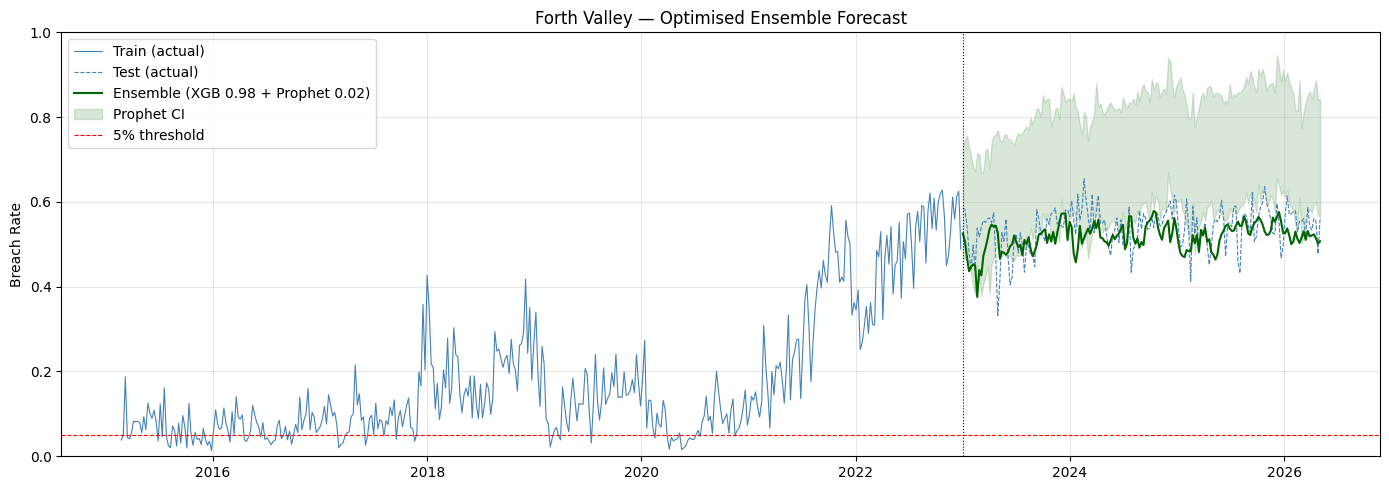

In [8]:
fv_ens = ensemble_df[ensemble_df['BoardName'] == 'Forth Valley'].sort_values('WeekEndingDate')
fv_train = df[(df['BoardName'] == 'Forth Valley') &
              (df['WeekEndingDate'] < '2023-01-01')]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(fv_train['WeekEndingDate'], fv_train['BreachRate'],
        color='steelblue', linewidth=0.8, label='Train (actual)')
ax.plot(fv_ens['WeekEndingDate'], fv_ens['BreachRate'],
        color='steelblue', linewidth=0.8, linestyle='--', label='Test (actual)')
ax.plot(fv_ens['WeekEndingDate'], fv_ens['pred_ensemble_opt'],
        color='darkgreen', linewidth=1.5, label=f'Ensemble (XGB {w_xgb_opt:.2f} + Prophet {w_prophet_opt:.2f})')
ax.fill_between(fv_ens['WeekEndingDate'],
                fv_ens['yhat_lower'].clip(0, 1),
                fv_ens['yhat_upper'].clip(0, 1),
                alpha=0.15, color='darkgreen', label='Prophet CI')
ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8, label='5% threshold')
ax.axvline(pd.Timestamp('2023-01-01'), color='black', linestyle=':', linewidth=0.8)
ax.set_title('Forth Valley — Optimised Ensemble Forecast')
ax.set_ylabel('Breach Rate')
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/ensemble_forth_valley.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
ensemble_df.to_csv('../data/processed/ensemble_predictions.csv', index=False)

results = pd.read_csv('../data/processed/model_results.csv')
ensemble_results = pd.DataFrame({
    'Model':  ['Ensemble 50/50', 'Ensemble Optimised'],
    'MAPE':   [round(mape_eq, 2), round(mape_opt, 2)],
    'RMSE':   [round(rmse_eq, 4), round(rmse_opt, 4)],
    'MAE':    [round(mae_eq, 4),  round(mae_opt, 4)],
    'Board':  ['All boards'] * 2,
    'Notes':  ['Equal weights', f'XGB={w_xgb_opt:.3f}, Prophet={w_prophet_opt:.3f}']
})
results = pd.concat([results, ensemble_results], ignore_index=True)
results.to_csv('../data/processed/model_results.csv', index=False)
print(results[['Model', 'MAPE', 'RMSE', 'MAE']].to_string())

                         Model   MAPE    RMSE     MAE
0             SARIMAX Baseline  71.77  0.4319  0.3836
1               SARIMAX + Exog  67.30  0.4061  0.3595
2             Prophet Baseline  66.51  0.3762  0.3541
3               Prophet + Exog  67.74  0.3826  0.3606
4       Prophet Logistic + Cap  28.45  0.1604  0.1487
5   Prophet Logistic + Plateau  28.98  0.1631  0.1515
6           XGBoost All Boards  10.55  0.0410  0.0318
7         XGBoost Forth Valley   8.39  0.0564  0.0448
8           XGBoost All Boards  10.55  0.0410  0.0318
9         XGBoost Forth Valley   8.39  0.0564  0.0448
10          XGBoost All Boards  10.55  0.0410  0.0318
11        XGBoost Forth Valley   8.39  0.0564  0.0448
12              Ensemble 50/50  32.50  0.1142  0.0989
13          Ensemble Optimised  10.51  0.0404  0.0313
